## Unzipping the dataset

In [1]:
!unzip -q volleyball_data.zip

## Format YOLO Labels
Custom Dataset to load images and labels.
Converts YOLO format labels (normalized center x,y, w, h) into absolute bounding box coordinates [xmin, ymin, xmax, ymax] as required by PyTorch object detection models.

In [ ]:
import os
import torch
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import functional as F

class VolleyballDataset(Dataset):
    def __init__(self, images_dir, labels_dir):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.image_names = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))]

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        height, width, _ = image.shape

        image_tensor = F.to_tensor(image)

        label_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
        label_path = os.path.join(self.labels_dir, label_name)

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_center, y_center, w, h = map(float, line.strip().split())

                    xmin = (x_center - w / 2) * width
                    ymin = (y_center - h / 2) * height
                    xmax = (x_center + w / 2) * width
                    ymax = (y_center + h / 2) * height

                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])

        return image_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = VolleyballDataset(images_dir='data/train/images', labels_dir='data/train/labels')
val_dataset = VolleyballDataset(images_dir='data/valid/images', labels_dir='data/valid/labels')

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

print(f"Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images.")


Loaded 521 training images and 27 validation images.


## Metrics
Calculates mAP@50 for the given model and validation loader

In [ ]:
%pip install torchmetrics -q

import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def evaluate_model(model, val_loader, device):
    """Calculates mAP@50 for the given model and validation loader."""
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")

    with torch.no_grad():
        for images, targets in val_loader:
            images = list(image.to(device) for image in images)

            formatted_targets = [{"boxes": t["boxes"].to(device), "labels": t["labels"].to(device)} for t in targets]

            predictions = model(images)

            formatted_preds = [{"boxes": p["boxes"].to(device), "scores": p["scores"].to(device), "labels": p["labels"].to(device)} for p in predictions]

            metric.update(formatted_preds, formatted_targets)

    result = metric.compute()
    return result['map_50'].item() * 100 # Return as percentage

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.7 MB/s eta 0:00:00


## Faster RCNN

In [11]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

model = get_model(num_classes=2)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

print(f"Model loaded and moved to: {device}")

Model loaded and moved to: cuda


In [ ]:
num_epochs = 50
loss_history_rcnn = []
map_history_rcnn = []

print("Starting Faster R-CNN training...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        epoch_loss += losses.item()

    average_loss = epoch_loss / len(train_loader)
    loss_history_rcnn.append(average_loss)

    map_50 = evaluate_model(model, val_loader, device)
    map_history_rcnn.append(map_50)

    print(f"Epoch {epoch+1}/{num_epochs} | Average Loss: {average_loss:.4f} | Val mAP@50: {map_50:.2f}%")

print("Initial training complete!")

Starting Faster R-CNN training...
Epoch 1/50 | Average Loss: 0.1428 | Val mAP@50: 96.04%
Epoch 2/50 | Average Loss: 0.0635 | Val mAP@50: 96.04%
Epoch 3/50 | Average Loss: 0.0503 | Val mAP@50: 96.04%
Epoch 4/50 | Average Loss: 0.0425 | Val mAP@50: 96.04%
Epoch 5/50 | Average Loss: 0.0372 | Val mAP@50: 96.04%
Epoch 6/50 | Average Loss: 0.0338 | Val mAP@50: 96.04%
Epoch 7/50 | Average Loss: 0.0306 | Val mAP@50: 96.04%
Epoch 8/50 | Average Loss: 0.0274 | Val mAP@50: 96.04%
Epoch 9/50 | Average Loss: 0.0262 | Val mAP@50: 96.04%
Epoch 10/50 | Average Loss: 0.0237 | Val mAP@50: 96.04%
Epoch 11/50 | Average Loss: 0.0223 | Val mAP@50: 96.04%
Epoch 12/50 | Average Loss: 0.0217 | Val mAP@50: 96.04%
Epoch 13/50 | Average Loss: 0.0198 | Val mAP@50: 96.04%
Epoch 14/50 | Average Loss: 0.0183 | Val mAP@50: 96.04%
Epoch 15/50 | Average Loss: 0.0184 | Val mAP@50: 96.04%
Epoch 16/50 | Average Loss: 0.0179 | Val mAP@50: 96.04%
Epoch 17/50 | Average Loss: 0.0156 | Val mAP@50: 96.04%
Epoch 18/50 | Average L

In [13]:
import torch

save_path = 'faster_rcnn_volleyball.pth'

torch.save(model.state_dict(), save_path)

print(f"Model weights successfully saved to {save_path}")

Model weights successfully saved to faster_rcnn_volleyball.pth


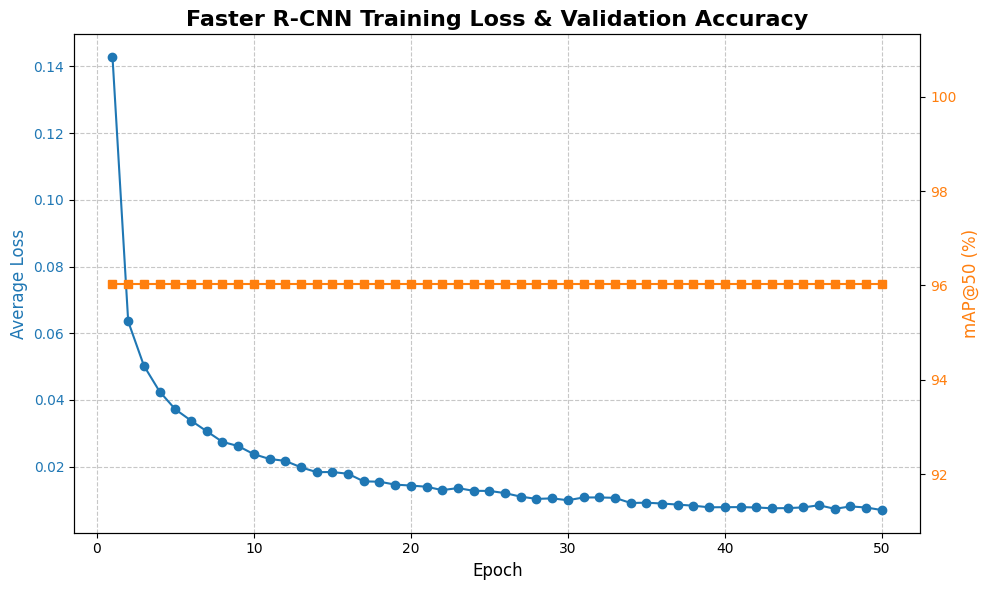

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(loss_history_rcnn) + 1))
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Average Loss', color=color, fontsize=12)
ax1.plot(epochs, loss_history_rcnn, marker='o', linestyle='-', color=color, label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('mAP@50 (%)', color=color, fontsize=12)
ax2.plot(epochs, map_history_rcnn, marker='s', linestyle='-', color=color, label='Validation mAP@50')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Faster R-CNN Training Loss & Validation Accuracy', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.savefig('faster_rcnn_loss_map_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## SSD 300

In [ ]:
import torchvision
import torch

print("Loading fresh SSD300 Architecture...")

ssd_model = torchvision.models.detection.ssd300_vgg16(weights_backbone='DEFAULT', num_classes=2)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
ssd_model.to(device)

params = [p for p in ssd_model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.0005, momentum=0.9, weight_decay=0.0005)

print("Fresh SSD Model loaded and ready!")

Loading fresh SSD300 Architecture...
Fresh SSD Model loaded and ready!


In [ ]:
num_epochs = 50
loss_history_ssd = []
map_history_ssd = []

print("Starting SSD training (with Gradient Clipping)...")

for epoch in range(num_epochs):
    ssd_model.train()
    epoch_loss = 0

    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = ssd_model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(ssd_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += losses.item()

    average_loss = epoch_loss / len(train_loader)
    loss_history_ssd.append(average_loss)

    map_50 = evaluate_model(ssd_model, val_loader, device)
    map_history_ssd.append(map_50)

    print(f"Epoch {epoch+1}/{num_epochs} | Average Loss: {average_loss:.4f} | Val mAP@50: {map_50:.2f}%")

print("SSD Training Complete!")

Starting SSD training (with Gradient Clipping)...
Epoch 1/50 | Average Loss: 43.7998 | Val mAP@50: 0.00%
Epoch 2/50 | Average Loss: 15.2475 | Val mAP@50: 0.00%
Epoch 3/50 | Average Loss: 7.0322 | Val mAP@50: 0.02%
Epoch 4/50 | Average Loss: 5.1990 | Val mAP@50: 0.09%
Epoch 5/50 | Average Loss: 4.8865 | Val mAP@50: 0.30%
Epoch 6/50 | Average Loss: 4.7599 | Val mAP@50: 0.31%
Epoch 7/50 | Average Loss: 4.6417 | Val mAP@50: 0.03%
Epoch 8/50 | Average Loss: 4.5546 | Val mAP@50: 0.40%
Epoch 9/50 | Average Loss: 4.4740 | Val mAP@50: 0.86%
Epoch 10/50 | Average Loss: 4.4065 | Val mAP@50: 1.33%
Epoch 11/50 | Average Loss: 4.3501 | Val mAP@50: 0.84%
Epoch 12/50 | Average Loss: 4.2526 | Val mAP@50: 0.63%
Epoch 13/50 | Average Loss: 4.1664 | Val mAP@50: 1.35%
Epoch 14/50 | Average Loss: 4.0826 | Val mAP@50: 0.32%
Epoch 15/50 | Average Loss: 3.9729 | Val mAP@50: 4.07%
Epoch 16/50 | Average Loss: 3.9096 | Val mAP@50: 5.38%
Epoch 17/50 | Average Loss: 3.7933 | Val mAP@50: 2.77%
Epoch 18/50 | Average 

In [ ]:
save_path = 'ssd_volleyball.pth'
torch.save(ssd_model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to ssd_volleyball.pth


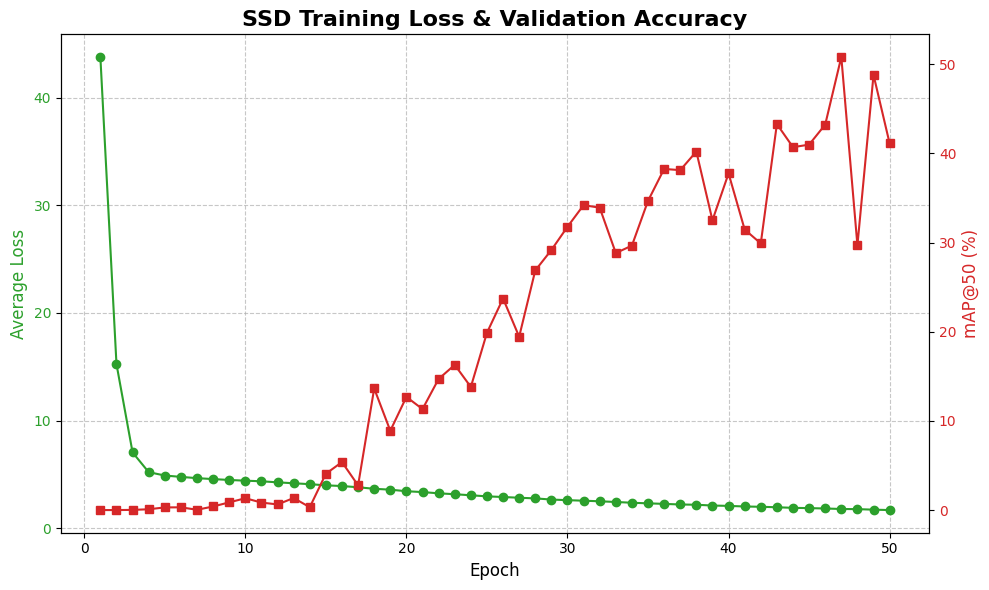

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(loss_history_ssd) + 1))
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:green'
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Average Loss', color=color, fontsize=12)
ax1.plot(epochs, loss_history_ssd, marker='o', linestyle='-', color=color, label='SSD Training Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('mAP@50 (%)', color=color, fontsize=12)
ax2.plot(epochs, map_history_ssd, marker='s', linestyle='-', color=color, label='Validation mAP@50')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('SSD Training Loss & Validation Accuracy', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.savefig('ssd_loss_map_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## RetinaNet


In [ ]:
import torchvision
import torch

print("Loading RetinaNet Architecture...")

retinanet_model = torchvision.models.detection.retinanet_resnet50_fpn(weights_backbone='DEFAULT', num_classes=2)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
retinanet_model.to(device)

params = [p for p in retinanet_model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.0005, momentum=0.9, weight_decay=0.0005)

print(f"RetinaNet Model loaded and moved to: {device}")

Loading RetinaNet Architecture...
RetinaNet Model loaded and moved to: cuda


In [ ]:
num_epochs = 50
loss_history_retinanet = []
map_history_retinanet = []

print("Starting RetinaNet training...")

for epoch in range(num_epochs):
    retinanet_model.train()
    epoch_loss = 0

    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = retinanet_model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(retinanet_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += losses.item()

    average_loss = epoch_loss / len(train_loader)
    loss_history_retinanet.append(average_loss)

    map_50 = evaluate_model(retinanet_model, val_loader, device)
    map_history_retinanet.append(map_50)

    print(f"Epoch {epoch+1}/{num_epochs} | Average Loss: {average_loss:.4f} | Val mAP@50: {map_50:.2f}%")

print("RetinaNet Training Complete!")

Starting RetinaNet training...
Epoch 1/50 | Average Loss: 2.3301 | Val mAP@50: 0.00%
Epoch 2/50 | Average Loss: 1.6121 | Val mAP@50: 0.00%
Epoch 3/50 | Average Loss: 1.4137 | Val mAP@50: 0.06%
Epoch 4/50 | Average Loss: 1.3323 | Val mAP@50: 5.62%
Epoch 5/50 | Average Loss: 1.2642 | Val mAP@50: 8.88%
Epoch 6/50 | Average Loss: 1.1890 | Val mAP@50: 12.74%
Epoch 7/50 | Average Loss: 1.0214 | Val mAP@50: 25.18%
Epoch 8/50 | Average Loss: 0.8286 | Val mAP@50: 36.17%
Epoch 9/50 | Average Loss: 0.7386 | Val mAP@50: 44.42%
Epoch 10/50 | Average Loss: 0.6840 | Val mAP@50: 49.48%
Epoch 11/50 | Average Loss: 0.6430 | Val mAP@50: 48.54%
Epoch 12/50 | Average Loss: 0.6002 | Val mAP@50: 54.59%
Epoch 13/50 | Average Loss: 0.5738 | Val mAP@50: 54.73%
Epoch 14/50 | Average Loss: 0.5533 | Val mAP@50: 57.70%
Epoch 15/50 | Average Loss: 0.5340 | Val mAP@50: 61.20%
Epoch 16/50 | Average Loss: 0.5144 | Val mAP@50: 63.57%
Epoch 17/50 | Average Loss: 0.5009 | Val mAP@50: 69.36%
Epoch 18/50 | Average Loss: 0.4

Model saved to retinanet_volleyball.pth


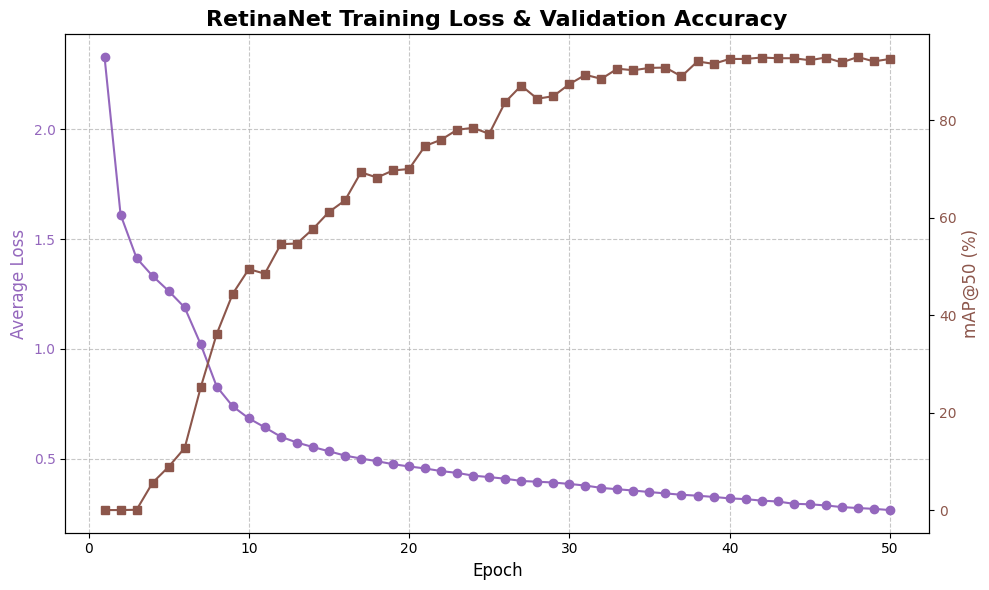

In [22]:
import matplotlib.pyplot as plt

save_path = 'retinanet_volleyball.pth'
torch.save(retinanet_model.state_dict(), save_path)
print(f"Model saved to {save_path}")

epochs = list(range(1, len(loss_history_retinanet) + 1))
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:purple'
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Average Loss', color=color, fontsize=12)
ax1.plot(epochs, loss_history_retinanet, marker='o', linestyle='-', color=color, label='RetinaNet Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
color = 'tab:brown'
ax2.set_ylabel('mAP@50 (%)', color=color, fontsize=12)
ax2.plot(epochs, map_history_retinanet, marker='s', linestyle='-', color=color, label='Validation mAP@50')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('RetinaNet Training Loss & Validation Accuracy', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.savefig('retinanet_loss_map_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## YOLOv8

In [ ]:
%pip install ultralytics -q

from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='dataset.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    name='volleyball_model'
)

In [ ]:
from IPython.display import Image, display

results_img_path = 'runs/detect/volleyball_model/results.png'

print("Training Progress Curves:")
display(Image(filename=results_img_path))

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8m.pt') 

results = model.train(
    data='dataset.yaml',   
    epochs=50,                
    imgsz=640,                
    batch=16,                 
    name='volleyball_model_medium'
)